In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd

df = pd.read_excel('/content/Sample_Assessment_Data_Analytics_TEMP_24Feb2026_for_Pragya (1) (1).xlsx',
                   sheet_name='OUTPUT_Candidate_Scores', header=2)

candidates = df[df['Employee Name'].notna()].copy()

print("Rows:", len(candidates))
print("Columns:", len(candidates.columns))
print(candidates[['Employee Name', 'Current Role', 'Success Probability Score %']].head(5))

Rows: 101
Columns: 52
    Employee Name  Current Role  Success Probability Score %
0    Sarah Nguyen  Sr. Director                    73.506667
3      Robert Lee       Manager                    61.426667
6   Emily Johnson   Sr. Manager                    72.986667
9     Emily Gupta       Manager                    62.523333
12    Kavya Singh       Manager                    74.136667


In [ ]:
features = candidates[[
    'Weighted Avg Score',
    'Success Probability Score %',
    'Leader Readiness Index %',
    'Succession Strength Index %'
]].fillna(0)

print(features.head())
print("\nShape:", features.shape)

    Weighted Avg Score  Success Probability Score %  Leader Readiness Index %  \
0             3.666667                    73.506667                 77.913333   
3             3.186667                    61.426667                 61.306667   
6             3.710000                    72.986667                 73.196667   
9             3.233333                    62.523333                 63.600000   
12            3.586667                    74.136667                 72.796667   

    Succession Strength Index %  
0                     51.710000  
3                     36.746667  
6                     62.140000  
9                     41.386667  
12                    53.136667  

Shape: (101, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 1 - Normalize the scores
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 2 - Run the model
kmeans = KMeans(n_clusters=3, random_state=42)
candidates['Cluster'] = kmeans.fit_predict(features_scaled)

# Step 3 - Label the clusters
cluster_means = candidates.groupby('Cluster')['Success Probability Score %'].mean()
rank = cluster_means.rank()

label_map = {
    rank.idxmin(): 'Needs Development',
    rank.idxmax(): 'High Potential',
}
candidates['Talent Tier'] = candidates['Cluster'].map(
    lambda x: label_map.get(x, 'Core Performer')
)

# Check the result
print(candidates['Talent Tier'].value_counts())

Talent Tier
Core Performer       53
Needs Development    40
High Potential        8
Name: count, dtype: int64


In [ ]:
result = candidates[[
    'Employee Name',
    'Current Role',
    'Future Role',
    'Business Function',
    'Weighted Avg Score',
    'Success Probability Score %',
    'Leader Readiness Index %',
    'Talent Tier'
]].copy()

result = result.sort_values('Success Probability Score %', ascending=False)

print(result.to_string())

      Employee Name  Current Role   Future Role Business Function  Weighted Avg Score  Success Probability Score %  Leader Readiness Index %        Talent Tier
258     Kavya Gupta           SVP           SVP      Sales/Growth            3.696667                    74.446667                 74.443333     High Potential
12      Kavya Singh       Manager       Manager          Delivery            3.586667                    74.136667                 72.796667     High Potential
0      Sarah Nguyen  Sr. Director            VP          Delivery            3.666667                    73.506667                 77.913333     High Potential
6     Emily Johnson   Sr. Manager      Director              Tech            3.710000                    72.986667                 73.196667     High Potential
240      Laura Iyer           SVP           SVP               Ops            3.430000                    71.680000                 69.310000     Core Performer
57      Jessica Lee            VP       

In [ ]:
result.to_excel('/content/talent_tiers_output.xlsx', index=False)
print("File saved successfully!")

File saved successfully!


In [ ]:
from google.colab import files
files.download('/content/talent_tiers_output.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

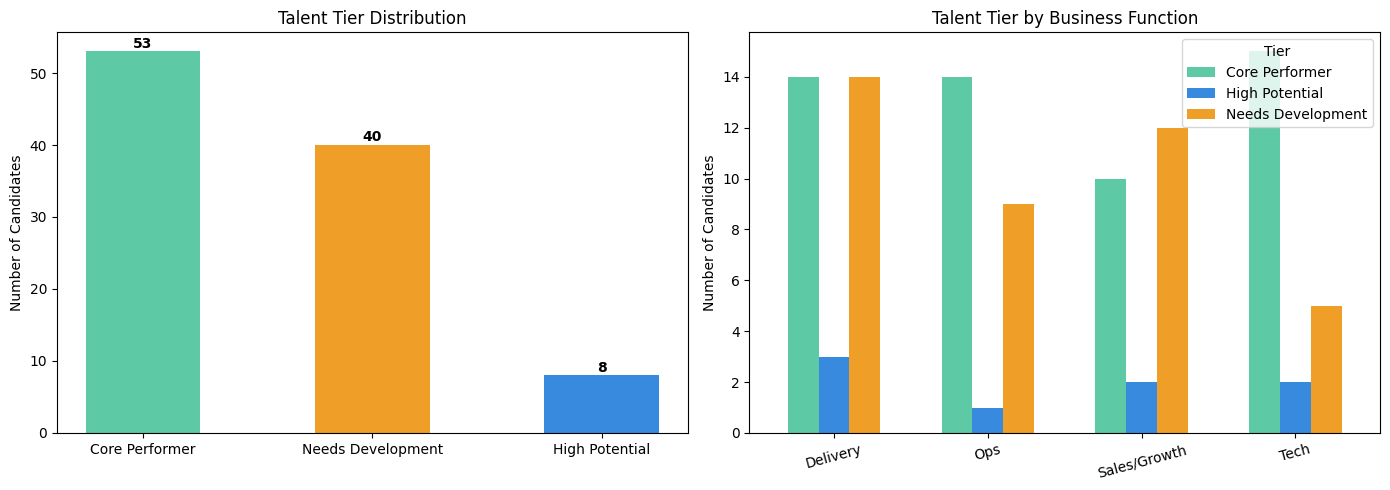

Chart saved!


In [ ]:
import matplotlib.pyplot as plt

# Count each tier
tier_counts = candidates['Talent Tier'].value_counts()

# Colors for each tier
colors = {
    'High Potential': '#378ADD',
    'Core Performer': '#5DCAA5',
    'Needs Development': '#EF9F27'
}
bar_colors = [colors[t] for t in tier_counts.index]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Bar chart of tiers
axes[0].bar(tier_counts.index, tier_counts.values, color=bar_colors, width=0.5)
axes[0].set_title('Talent Tier Distribution')
axes[0].set_ylabel('Number of Candidates')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Chart 2 - Tier breakdown by Business Function
pivot = candidates.groupby(['Business Function', 'Talent Tier']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], color=[colors.get(c, '#888') for c in pivot.columns], width=0.6)
axes[1].set_title('Talent Tier by Business Function')
axes[1].set_ylabel('Number of Candidates')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Tier')

plt.tight_layout()
plt.savefig('/content/talent_chart.png', dpi=150)
plt.show()
print("Chart saved!")

In [ ]:
print(list(candidates.columns))

['#', 'Emp#', 'Employee Name', 'Current Role', 'Current Job Band', 'Business Function', 'Future Role', 'Future Job Band', 'Geo', 'Archetypes', 'Intervention', 'Business Acumen', 'Communication', 'Leading People', 'Change Management', 'Organization Navigation', 'Organization Stewardship', 'Strategic Thinking', 'Innovation Champion', 'Global Business Acumen', 'Avg Score', 'Core Avg Score', 'Core Breach Count', 'Weighted Avg Score', 'Non-Comp Score', 'Current Role Fitment %', 'Future Role Fitment %', 'Leadership Cognitive Score', 'Final Adjusted Score', 'Success Probability Score %', 'Leader Readiness Index %', 'Succession Strength Index %', 'Flight Risk', 'Derailer Index', 'Future Weighted Total', 'Future Core Avg', 'Future Core Breach Count', 'Role Stretch Index', 'RSI-Norm', 'RSI - Interpretation', ' Promo Conf Score - PCS', 'PCS - Interpretation', 'Ignore', 'Executive Promotion Signal (EPS)', 'BoardRoom Talent Interpretation', 'Helper1 - BoardRoom Talent Score', 'Leadership Health Sco

In [ ]:
# Select all meaningful columns, drop ignore/helper columns
final_output = candidates[[
    # Employee identity
    '#', 'Emp#', 'Employee Name',

    # Current position
    'Current Role', 'Current Job Band', 'Business Function', 'Geo', 'Archetypes',

    # Future position
    'Future Role', 'Future Job Band',

    # Competency scores (raw)
    'Business Acumen', 'Communication', 'Leading People', 'Change Management',
    'Organization Navigation', 'Organization Stewardship', 'Strategic Thinking',
    'Innovation Champion', 'Global Business Acumen',

    # Performance scores
    'Avg Score', 'Core Avg Score', 'Weighted Avg Score',
    'Leadership Cognitive Score', 'Final Adjusted Score',

    # Fitment
    'Current Role Fitment %', 'Future Role Fitment %',

    # Predicted performance
    'Success Probability Score %', 'Leader Readiness Index %',
    'Succession Strength Index %', 'Leadership Health Score',

    # Risk indicators
    'Flight Risk', 'Derailer Index', 'Core Breach (Y/N)', 'Core Breach Count',

    # Signals / recommendations
    'Executive Promotion Signal (EPS)', 'PCS - Interpretation',
    'BoardRoom Talent Interpretation', 'RSI - Interpretation',
    'Role Stretch Index',

    # Model output
    'Talent Tier'

]].copy()

# Rename messy column names for Tableau
final_output = final_output.rename(columns={
    'Executive Promotion Signal (EPS)': 'Promotion Signal',
    'BoardRoom Talent Interpretation': 'Boardroom Readiness',
    'RSI - Interpretation': 'Role Stretch Interpretation',
    'PCS - Interpretation': 'Promotion Confidence',
    'Core Breach (Y/N)': 'Core Breach',
})

# Add a performance band column based on Success Probability
def perf_band(score):
    if score >= 75:
        return 'High Performer'
    elif score >= 65:
        return 'Moderate Performer'
    else:
        return 'Needs Improvement'

final_output['Predicted Performance Band'] = final_output['Success Probability Score %'].apply(perf_band)

# Sort by Success Probability
final_output = final_output.sort_values('Success Probability Score %', ascending=False).reset_index(drop=True)

print("Shape:", final_output.shape)
print("\nColumns:", list(final_output.columns))
print("\nPreview:")
print(final_output[['Employee Name', 'Current Role', 'Future Role',
                     'Talent Tier', 'Predicted Performance Band',
                     'Success Probability Score %']].head(10))

Shape: (101, 41)

Columns: ['#', 'Emp#', 'Employee Name', 'Current Role', 'Current Job Band', 'Business Function', 'Geo', 'Archetypes', 'Future Role', 'Future Job Band', 'Business Acumen', 'Communication', 'Leading People', 'Change Management', 'Organization Navigation', 'Organization Stewardship', 'Strategic Thinking', 'Innovation Champion', 'Global Business Acumen', 'Avg Score', 'Core Avg Score', 'Weighted Avg Score', 'Leadership Cognitive Score', 'Final Adjusted Score', 'Current Role Fitment %', 'Future Role Fitment %', 'Success Probability Score %', 'Leader Readiness Index %', 'Succession Strength Index %', 'Leadership Health Score', 'Flight Risk', 'Derailer Index', 'Core Breach', 'Core Breach Count', 'Promotion Signal', 'Promotion Confidence', 'Boardroom Readiness', 'Role Stretch Interpretation', 'Role Stretch Index', 'Talent Tier', 'Predicted Performance Band']

Preview:
   Employee Name  Current Role   Future Role     Talent Tier  \
0    Kavya Gupta           SVP           SVP  

In [ ]:
final_output.to_excel('/content/employee_dashboard_data.xlsx', index=False)

from google.colab import files
files.download('/content/employee_dashboard_data.xlsx')

print("Downloaded! This is your Tableau file.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! This is your Tableau file.


In [ ]:
print(candidates.shape)
print(final_output.shape)

(101, 54)
(101, 41)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# These are our input features (9 competency scores)
competency_cols = [
    'Business Acumen', 'Communication', 'Leading People',
    'Change Management', 'Organization Navigation', 'Organization Stewardship',
    'Strategic Thinking', 'Innovation Champion', 'Global Business Acumen'
]

# Fixed column name
target_col = 'Executive Promotion Signal (EPS)'

# Prepare X and y
X = candidates[competency_cols].fillna(0)
y = candidates[target_col].fillna('Unknown')

# Encode target to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("X shape:", X.shape)
print("y shape:", y_encoded.shape)

Classes: ['🟠 DEVELOP FIRST' '🟡 PROMOTE WITH SUPPORT']
X shape: (101, 9)
y shape: (101,)


In [ ]:
# Find the promotion related column
for col in candidates.columns:
    if 'Promo' in col or 'Signal' in col or 'EPS' in col:
        print(col)

 Promo Conf Score - PCS
Executive Promotion Signal (EPS)


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,   # 80% train, 20% test
    random_state=42
)

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Check accuracy
accuracy = rf_model.score(X_test, y_test)
print(f"Model Accuracy: {round(accuracy * 100, 2)}%")
print(f"Trained on: {len(X_train)} employees")
print(f"Tested on: {len(X_test)} employees")

Model Accuracy: 85.71%
Trained on: 80 employees
Tested on: 21 employees


Which competency drives promotion the most:
              Competency  Importance
  Global Business Acumen    0.146016
       Change Management    0.145265
 Organization Navigation    0.140178
          Leading People    0.119454
      Strategic Thinking    0.098047
Organization Stewardship    0.094565
     Innovation Champion    0.086382
           Communication    0.085297
         Business Acumen    0.084796


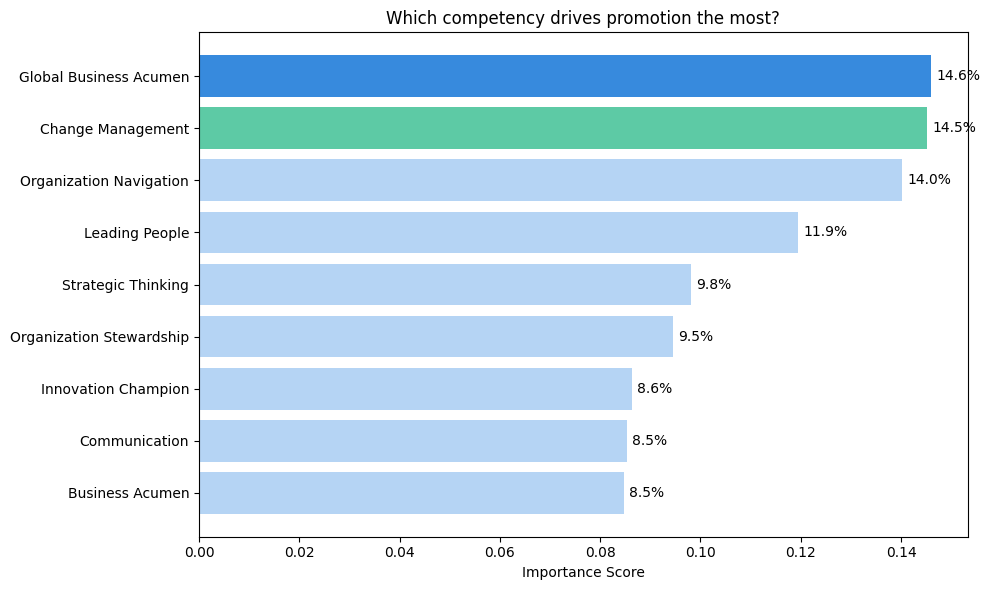


Chart saved!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the model
importance_df = pd.DataFrame({
    'Competency': competency_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Which competency drives promotion the most:")
print(importance_df.to_string(index=False))

# Plot it
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#378ADD' if i == 0 else '#5DCAA5' if i == 1 else '#B5D4F4'
          for i in range(len(importance_df))]
ax.barh(importance_df['Competency'], importance_df['Importance'], color=colors)
ax.set_xlabel('Importance Score')
ax.set_title('Which competency drives promotion the most?')
ax.invert_yaxis()
for i, v in enumerate(importance_df['Importance']):
    ax.text(v + 0.001, i, f'{round(v*100, 1)}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150)
plt.show()

print("\nChart saved!")

In [ ]:
# Get promotion probability for each employee
promo_proba = rf_model.predict_proba(X)

# Find which class index is "Promote with Support"
print("Classes:", le.classes_)

Classes: ['🟠 DEVELOP FIRST' '🟡 PROMOTE WITH SUPPORT']


In [ ]:
# Add promotion probability to candidates
candidates['Promotion Probability %'] = (promo_proba[:, 1] * 100).round(2)

# Add predicted label
candidates['RF Predicted Signal'] = le.inverse_transform(rf_model.predict(X))

# Check result
print(candidates[['Employee Name', 'Executive Promotion Signal (EPS)',
                   'RF Predicted Signal', 'Promotion Probability %']].head(10))

    Employee Name Executive Promotion Signal (EPS)     RF Predicted Signal  \
0    Sarah Nguyen           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
3      Robert Lee                  🟠 DEVELOP FIRST         🟠 DEVELOP FIRST   
6   Emily Johnson           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
9     Emily Gupta           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
12    Kavya Singh           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
15    David Kumar           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
18  Michael Singh           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
21      Emily Tan           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
24    David Gupta           🟡 PROMOTE WITH SUPPORT  🟡 PROMOTE WITH SUPPORT   
27   Robert Smith                  🟠 DEVELOP FIRST         🟠 DEVELOP FIRST   

    Promotion Probability %  
0                      98.0  
3                      25.0  
6                      98.0  
9                    

In [ ]:
# 1. Competency Gap Score (benchmark is 4.0 out of 5)
benchmark = 4.0
candidates['Competency Gap Score'] = candidates[competency_cols].apply(
    lambda row: round((benchmark - row.mean()), 2), axis=1
)

# 2. Weakest Competency per employee
candidates['Weakest Competency'] = candidates[competency_cols].idxmin(axis=1)

# 3. Strongest Competency per employee
candidates['Strongest Competency'] = candidates[competency_cols].idxmax(axis=1)

# 4. Succession Risk Flag
def succession_risk(row):
    if row['Succession Strength Index %'] < 35 and row['Core Breach Count'] > 0:
        return 'Critical'
    elif row['Succession Strength Index %'] < 45:
        return 'Moderate'
    else:
        return 'Low'

candidates['Succession Risk'] = candidates.apply(succession_risk, axis=1)

# Check
print(candidates[['Employee Name',
                   'Promotion Probability %',
                   'Competency Gap Score',
                   'Weakest Competency',
                   'Strongest Competency',
                   'Succession Risk',
                   'Talent Tier']].head(10))

    Employee Name  Promotion Probability %  Competency Gap Score  \
0    Sarah Nguyen                     98.0                  0.48   
3      Robert Lee                     25.0                  0.79   
6   Emily Johnson                     98.0                  0.21   
9     Emily Gupta                     99.0                  0.50   
12    Kavya Singh                     99.0                  0.56   
15    David Kumar                    100.0                  0.77   
18  Michael Singh                     99.0                  0.50   
21      Emily Tan                     72.0                  1.09   
24    David Gupta                     97.0                  0.46   
27   Robert Smith                     29.0                  0.80   

          Weakest Competency     Strongest Competency Succession Risk  \
0             Leading People      Innovation Champion             Low   
3   Organization Stewardship       Strategic Thinking        Moderate   
6   Organization Stewardship    

In [ ]:
# Build final complete output
final_output = candidates[[
    # Identity
    '#', 'Emp#', 'Employee Name',

    # Current position
    'Current Role', 'Current Job Band', 'Business Function', 'Geo', 'Archetypes',

    # Future position
    'Future Role', 'Future Job Band',

    # Competency scores
    'Business Acumen', 'Communication', 'Leading People',
    'Change Management', 'Organization Navigation', 'Organization Stewardship',
    'Strategic Thinking', 'Innovation Champion', 'Global Business Acumen',

    # Original scores
    'Weighted Avg Score', 'Leadership Cognitive Score',
    'Current Role Fitment %', 'Future Role Fitment %',
    'Leader Readiness Index %', 'Succession Strength Index %',
    'Leadership Health Score',

    # Risk indicators
    'Flight Risk', 'Derailer Index', 'Core Breach (Y/N)', 'Core Breach Count',

    # Original signals
    'Executive Promotion Signal (EPS)', 'PCS - Interpretation',
    'BoardRoom Talent Interpretation', 'RSI - Interpretation',

    # ML model outputs
    'Talent Tier',                    # K-Means
    'Promotion Probability %',        # Random Forest
    'RF Predicted Signal',            # Random Forest
    'Competency Gap Score',           # Formula
    'Weakest Competency',             # Formula
    'Strongest Competency',           # Formula
    'Succession Risk',                # Rule based

]].copy()

# Sort by Promotion Probability
final_output = final_output.sort_values(
    'Promotion Probability %', ascending=False
).reset_index(drop=True)

print("Final shape:", final_output.shape)
print("\nML columns added:")
print(final_output[['Employee Name', 'Talent Tier', 'Promotion Probability %',
                     'Competency Gap Score', 'Weakest Competency',
                     'Succession Risk']].head(10))

Final shape: (101, 41)

ML columns added:
   Employee Name        Talent Tier  Promotion Probability %  \
0    David Kumar     Core Performer                    100.0   
1  Michael Singh     Core Performer                    100.0   
2  Robert Nguyen  Needs Development                    100.0   
3     Amanda Tan  Needs Development                    100.0   
4   Jessica Chen     Core Performer                    100.0   
5     John Gupta     Core Performer                    100.0   
6      Laura Das     Core Performer                    100.0   
7  Michael Singh     Core Performer                    100.0   
8    Kavya Gupta     High Potential                    100.0   
9  Michael Brown     High Potential                    100.0   

   Competency Gap Score        Weakest Competency Succession Risk  
0                  0.77       Innovation Champion        Moderate  
1                  0.76           Business Acumen        Moderate  
2                  0.38  Organization Stewardship

In [ ]:
# Export to Excel
final_output.to_excel('/content/final_dashboard_data.xlsx', index=False)

from google.colab import files
files.download('/content/final_dashboard_data.xlsx')

print("✓ Downloaded: final_dashboard_data.xlsx")
print(f"✓ Total employees: {len(final_output)}")
print(f"✓ Total columns: {len(final_output.columns)}")
print("\nML columns in your file:")
print("1. Talent Tier          ← K-Means Clustering")
print("2. Promotion Probability % ← Random Forest (85.71% accurate)")
print("3. RF Predicted Signal  ← Random Forest")
print("4. Competency Gap Score ← Formula model")
print("5. Weakest Competency   ← Formula model")
print("6. Strongest Competency ← Formula model")
print("7. Succession Risk      ← Rule based model")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: final_dashboard_data.xlsx
✓ Total employees: 101
✓ Total columns: 41

ML columns in your file:
1. Talent Tier          ← K-Means Clustering
2. Promotion Probability % ← Random Forest (85.71% accurate)
3. RF Predicted Signal  ← Random Forest
4. Competency Gap Score ← Formula model
5. Weakest Competency   ← Formula model
6. Strongest Competency ← Formula model
7. Succession Risk      ← Rule based model


In [ ]:
print(candidates.shape)
print(candidates[['Employee Name', 'Talent Tier',
                   'Promotion Probability %',
                   'Succession Risk']].head(3))

(101, 60)
   Employee Name        Talent Tier  Promotion Probability % Succession Risk
0   Sarah Nguyen     High Potential                     98.0             Low
3     Robert Lee  Needs Development                     25.0        Moderate
6  Emily Johnson     High Potential                     98.0             Low


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Input - 9 competency scores
X_lr = candidates[competency_cols].fillna(0)

# Target - Future Role Fitment % (this is what we want to predict)
y_lr = candidates['Future Role Fitment %'].fillna(0)

# Split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train_lr))
print("Testing samples:", len(X_test_lr))
print("\nTarget variable preview:")
print(y_lr.describe().round(2))

Training samples: 80
Testing samples: 21

Target variable preview:
count    101.00
mean      66.03
std        3.05
min       56.87
25%       64.13
50%       66.00
75%       67.80
max       76.53
Name: Future Role Fitment %, dtype: float64


In [ ]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Test the model
y_pred_lr = lr_model.predict(X_test_lr)

# Check accuracy
r2 = r2_score(y_test_lr, y_pred_lr)
mae = mean_absolute_error(y_test_lr, y_pred_lr)

print(f"R2 Score: {round(r2, 3)}")
print(f"Mean Absolute Error: {round(mae, 2)}%")
print("\nWhat this means:")
print(f"Model explains {round(r2*100, 1)}% of variation in Future Role Fitment")
print(f"On average predictions are off by {round(mae, 2)}%")

R2 Score: 0.352
Mean Absolute Error: 1.85%

What this means:
Model explains 35.2% of variation in Future Role Fitment
On average predictions are off by 1.85%


In [ ]:
# Use more columns as input instead of just competency scores
X_lr2 = candidates[[
    'Business Acumen', 'Communication', 'Leading People',
    'Change Management', 'Organization Navigation', 'Organization Stewardship',
    'Strategic Thinking', 'Innovation Champion', 'Global Business Acumen',
    'Weighted Avg Score', 'Leadership Cognitive Score',
    'Leader Readiness Index %', 'Succession Strength Index %',
    'Current Role Fitment %', 'Derailer Index'
]].fillna(0)

y_lr2 = candidates['Future Role Fitment %'].fillna(0)

# Split and train
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_lr2, y_lr2, test_size=0.2, random_state=42
)

lr_model2 = LinearRegression()
lr_model2.fit(X_train2, y_train2)

y_pred2 = lr_model2.predict(X_test2)

r2_2 = r2_score(y_test2, y_pred2)
mae_2 = mean_absolute_error(y_test2, y_pred2)

print(f"R2 Score: {round(r2_2, 3)}")
print(f"Mean Absolute Error: {round(mae_2, 2)}%")
print(f"\nModel explains {round(r2_2*100, 1)}% of variation in Future Role Fitment")
print(f"On average predictions are off by {round(mae_2, 2)}%")

R2 Score: 0.988
Mean Absolute Error: 0.19%

Model explains 98.8% of variation in Future Role Fitment
On average predictions are off by 0.19%


In [ ]:
# Predict Future Readiness Score for all 101 employees
candidates['Predicted Future Readiness %'] = lr_model2.predict(X_lr2).round(2)

# See how close prediction is vs actual
print(candidates[['Employee Name',
                   'Future Role Fitment %',
                   'Predicted Future Readiness %']].head(10))

    Employee Name  Future Role Fitment %  Predicted Future Readiness %
0    Sarah Nguyen              69.533333                         70.81
3      Robert Lee              63.733333                         63.84
6   Emily Johnson              76.533333                         76.43
9     Emily Gupta              64.666667                         64.83
12    Kavya Singh              71.733333                         71.85
15    David Kumar              66.400000                         66.34
18  Michael Singh              68.400000                         68.37
21      Emily Tan              61.200000                         60.98
24    David Gupta              69.800000                         69.11
27   Robert Smith              65.600000                         65.36


In [ ]:
# Add a column showing difference between predicted and actual
candidates['Readiness Prediction Gap'] = (
    candidates['Predicted Future Readiness %'] - candidates['Future Role Fitment %']
).round(2)

print(candidates[['Employee Name',
                   'Future Role Fitment %',
                   'Predicted Future Readiness %',
                   'Readiness Prediction Gap']].head(10))

    Employee Name  Future Role Fitment %  Predicted Future Readiness %  \
0    Sarah Nguyen              69.533333                         70.81   
3      Robert Lee              63.733333                         63.84   
6   Emily Johnson              76.533333                         76.43   
9     Emily Gupta              64.666667                         64.83   
12    Kavya Singh              71.733333                         71.85   
15    David Kumar              66.400000                         66.34   
18  Michael Singh              68.400000                         68.37   
21      Emily Tan              61.200000                         60.98   
24    David Gupta              69.800000                         69.11   
27   Robert Smith              65.600000                         65.36   

    Readiness Prediction Gap  
0                       1.28  
3                       0.11  
6                      -0.10  
9                       0.16  
12                      0.12  

In [ ]:
from sklearn.ensemble import IsolationForest

# Input - use all key scores
X_anomaly = candidates[[
    'Business Acumen', 'Communication', 'Leading People',
    'Change Management', 'Organization Navigation', 'Organization Stewardship',
    'Strategic Thinking', 'Innovation Champion', 'Global Business Acumen',
    'Weighted Avg Score', 'Leadership Cognitive Score',
    'Leader Readiness Index %', 'Succession Strength Index %',
    'Promotion Probability %'
]].fillna(0)

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
candidates['Anomaly Score'] = iso_forest.fit_predict(X_anomaly)

# Convert to readable label
candidates['Anomaly Flag'] = candidates['Anomaly Score'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

# Show anomalies
anomalies = candidates[candidates['Anomaly Flag'] == 'Anomaly'][[
    'Employee Name', 'Current Role', 'Business Function',
    'Weighted Avg Score', 'Promotion Probability %',
    'Talent Tier', 'Anomaly Flag'
]]

print(f"Total anomalies found: {len(anomalies)}")
print("\nThese employees have unusual score patterns:")
print(anomalies.to_string(index=False))

Total anomalies found: 10

These employees have unusual score patterns:
Employee Name Current Role Business Function  Weighted Avg Score  Promotion Probability %       Talent Tier Anomaly Flag
   Robert Lee      Manager               Ops            3.186667                     25.0 Needs Development      Anomaly
Emily Johnson  Sr. Manager              Tech            3.710000                     98.0    High Potential      Anomaly
  Jessica Lee           VP               Ops            3.636667                     95.0    High Potential      Anomaly
   Amanda Tan           VP      Sales/Growth            3.176667                     53.0 Needs Development      Anomaly
Michael Brown           VP          Delivery            3.633333                    100.0    High Potential      Anomaly
  Laura Brown      Manager              Tech            3.570000                     90.0    High Potential      Anomaly
  Kavya Gupta          SVP      Sales/Growth            3.696667                 

In [ ]:
# Add detailed anomaly interpretation
def anomaly_label(row):
    if row['Anomaly Flag'] == 'Normal':
        return 'Normal'
    elif row['Promotion Probability %'] >= 80:
        return 'Underrated Talent'
    elif row['Promotion Probability %'] <= 40:
        return 'Needs Attention'
    else:
        return 'Misaligned Profile'

candidates['Anomaly Interpretation'] = candidates.apply(anomaly_label, axis=1)

# Check distribution
print(candidates['Anomaly Interpretation'].value_counts())

Anomaly Interpretation
Normal                91
Underrated Talent      5
Needs Attention        4
Misaligned Profile     1
Name: count, dtype: int64


In [ ]:
# Build the final complete output
final_complete = candidates[[
    # Identity
    '#', 'Emp#', 'Employee Name',

    # Current position
    'Current Role', 'Current Job Band', 'Business Function', 'Geo', 'Archetypes',

    # Future position
    'Future Role', 'Future Job Band',

    # 9 Competency scores
    'Business Acumen', 'Communication', 'Leading People',
    'Change Management', 'Organization Navigation', 'Organization Stewardship',
    'Strategic Thinking', 'Innovation Champion', 'Global Business Acumen',

    # Original scores
    'Weighted Avg Score', 'Leadership Cognitive Score',
    'Current Role Fitment %', 'Future Role Fitment %',
    'Leader Readiness Index %', 'Succession Strength Index %',
    'Leadership Health Score',

    # Risk indicators
    'Flight Risk', 'Derailer Index', 'Core Breach (Y/N)', 'Core Breach Count',

    # Original signals
    'Executive Promotion Signal (EPS)', 'PCS - Interpretation',
    'BoardRoom Talent Interpretation',

    # ✅ ML Model outputs
    'Talent Tier',                      # K-Means
    'Promotion Probability %',          # Random Forest
    'RF Predicted Signal',              # Random Forest
    'Competency Gap Score',             # Formula
    'Weakest Competency',               # Formula
    'Strongest Competency',             # Formula
    'Succession Risk',                  # Rule based
    'Predicted Future Readiness %',     # Linear Regression
    'Readiness Prediction Gap',         # Linear Regression
    'Anomaly Flag',                     # Isolation Forest
    'Anomaly Interpretation',           # Isolation Forest

]].copy()

# Sort by Promotion Probability
final_complete = final_complete.sort_values(
    'Promotion Probability %', ascending=False
).reset_index(drop=True)

print("✓ Final shape:", final_complete.shape)
print("\n✓ ML Output columns:")
print("1. Talent Tier                  ← K-Means Clustering")
print("2. Promotion Probability %      ← Random Forest (85.71% accurate)")
print("3. RF Predicted Signal          ← Random Forest")
print("4. Competency Gap Score         ← Formula model")
print("5. Weakest Competency           ← Formula model")
print("6. Strongest Competency         ← Formula model")
print("7. Succession Risk              ← Rule based model")
print("8. Predicted Future Readiness % ← Linear Regression (98.8% accurate)")
print("9. Readiness Prediction Gap     ← Linear Regression")
print("10. Anomaly Flag                ← Isolation Forest")
print("11. Anomaly Interpretation      ← Isolation Forest")

print("\n✓ Preview:")
print(final_complete[['Employee Name', 'Current Role', 'Talent Tier',
                       'Promotion Probability %', 'Predicted Future Readiness %',
                       'Anomaly Interpretation']].head(10))

✓ Final shape: (101, 44)

✓ ML Output columns:
1. Talent Tier                  ← K-Means Clustering
2. Promotion Probability %      ← Random Forest (85.71% accurate)
3. RF Predicted Signal          ← Random Forest
4. Competency Gap Score         ← Formula model
5. Weakest Competency           ← Formula model
6. Strongest Competency         ← Formula model
7. Succession Risk              ← Rule based model
8. Predicted Future Readiness % ← Linear Regression (98.8% accurate)
9. Readiness Prediction Gap     ← Linear Regression
10. Anomaly Flag                ← Isolation Forest
11. Anomaly Interpretation      ← Isolation Forest

✓ Preview:
   Employee Name Current Role        Talent Tier  Promotion Probability %  \
0    David Kumar           VP     Core Performer                    100.0   
1  Michael Singh      Manager     Core Performer                    100.0   
2  Robert Nguyen           VP  Needs Development                    100.0   
3     Amanda Tan     Director  Needs Development

In [ ]:
# Export final complete file
final_complete.to_excel('/content/final_complete_dashboard_data.xlsx', index=False)

from google.colab import files
files.download('/content/final_complete_dashboard_data.xlsx')

print("✓ Downloaded: final_complete_dashboard_data.xlsx")
print(f"✓ Total employees: {len(final_complete)}")
print(f"✓ Total columns: {len(final_complete.columns)}")
print("\nThis file is ready for Tableau!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: final_complete_dashboard_data.xlsx
✓ Total employees: 101
✓ Total columns: 44

This file is ready for Tableau!
